In [1]:
import os, datetime, sys, time, traceback
import pandas as pd
import numpy as np
import pickle as pkl
import multiprocessing as mp
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from statsmodels.distributions.empirical_distribution import ECDF
from skfda.exploratory.depth import ModifiedBandDepth
from scipy import stats
from functools import partial

from sklearn.neighbors import KernelDensity

sys.path.append('/home/gterren/dynamic_update/functional_forecast_dynamic_update/')

from src.fdu import functional_dynamic_update

from src.utils import (_KS, 
                       _weighted_empirical_interval_score, 
                       _empirical_PIT, 
                       _energy_score)

path_to_data = '/home/gterren/dynamic_update/data'
path_to_validation = '/home/gterren/dynamic_update/validation'
path_to_param = '/home/gterren/dynamic_update/params'
path_to_test = '/home/gterren/dynamic_update/test'
path_to_images = '/home/gterren/dynamic_update/images'

# Calibration experiments setup
T = 288
resource = 'wind'
method   = 'fusion'

In [2]:
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
print(F_tr_.shape, E_tr_.shape)
    
# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.
print(F_tr_.max(), E_tr_.max())
print(F_tr_.max(), E_tr_.min())

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.
print(F_ts_.max(), F_ts_.max())
print(F_ts_.min(), E_ts_.min())

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_bias_ = E_ts_.copy()
E_tr_bias_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
print(E_tr_bias_.shape, E_ts_bias_.shape)

(363, 288, 187) (363, 288, 187)
(364, 288, 187) (364, 288, 187)
1.0 0.9999999888984703
1.0 0.0
1.0 1.0
0.0 0.0
(67881, 288) (364, 288, 187)


(363, 288, 187) (363, 288, 187)


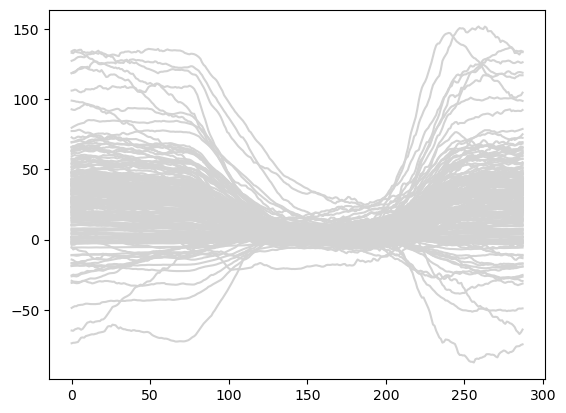

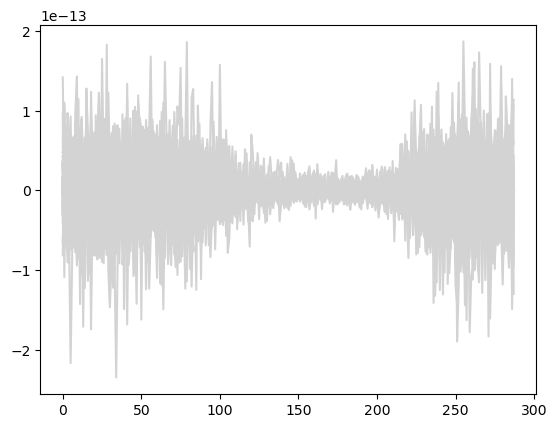

(364, 288, 187) (364, 288, 187)


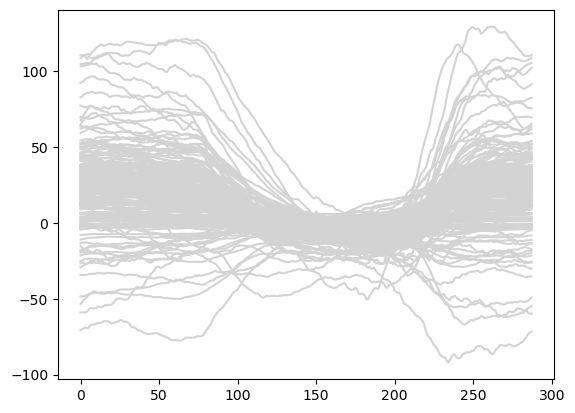

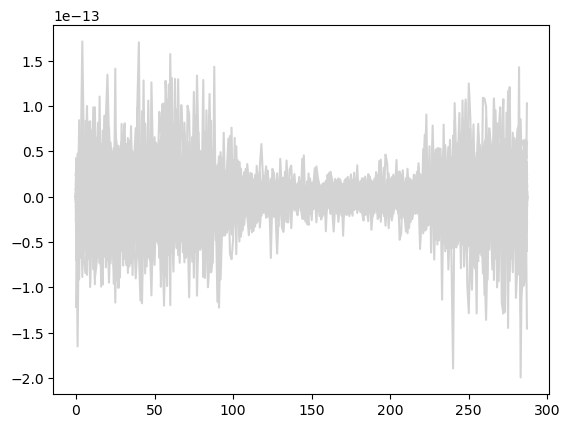

In [3]:
# Load 2017 data as training set
with open(path_to_data + f"/linear_preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
print(F_tr_.shape, E_tr_.shape)

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Load 2018 data as testing set
with open(path_to_data + f"/linear_preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape)

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
# print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_lin_ = E_ts_.copy()
E_tr_lin_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(E_tr_lin_.shape, E_ts_lin_.shape)

(363, 288, 187) (363, 288, 187) (363, 288)


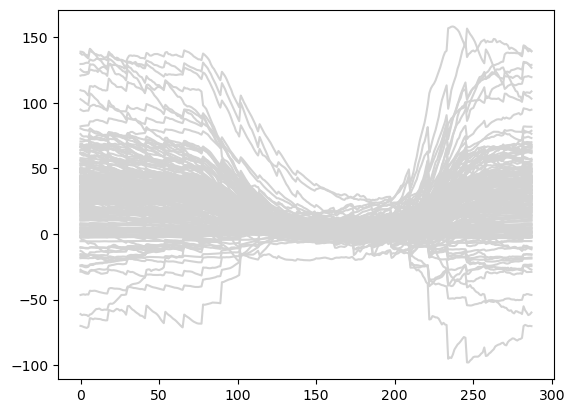

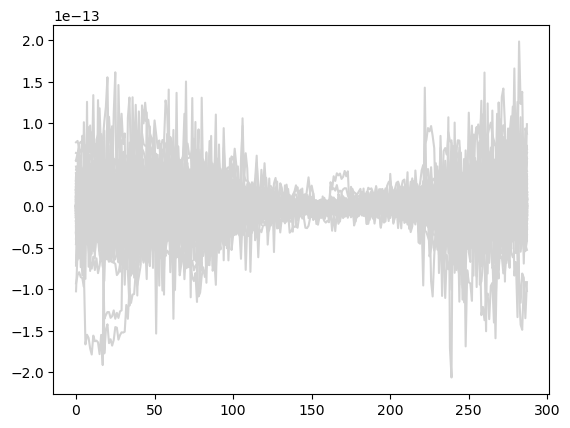

(364, 288, 187) (364, 288, 187) (364, 288)


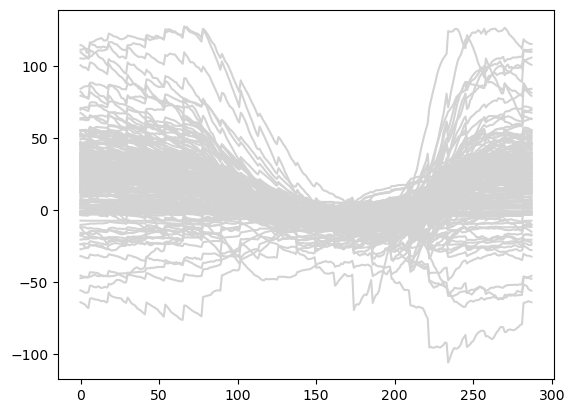

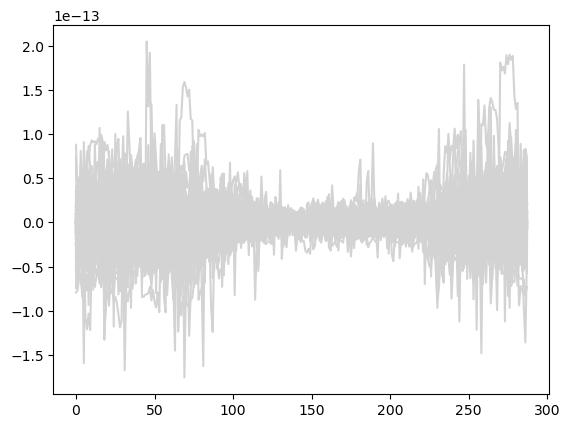

In [4]:
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
X_tr_      = _data["locations"]
dates_tr_  = _data["dates"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, X_tr_.shape, dates_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
T_tr_ = dates_tr_.reshape(int(dates_tr_.shape[0]/T), T)
print(F_tr_.shape, E_tr_.shape, T_tr_.shape)

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
X_ts_      = _data["locations"]
dates_ts_  = _data["dates"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, X_ts_.shape, dates_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
T_ts_ = dates_ts_.reshape(int(dates_ts_.shape[0]/T), T)
print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
#print(dt_.shape, dx_.shape)

# Short testing set with training set order
order      = {v: i for i, v in enumerate(assets_tr_)}
idx_       = np.argsort([order[x] for x in assets_ts_])
assets_ts_ = assets_ts_[idx_]
X_ts_      = X_ts_[idx_]
F_ts_      = F_ts_[:, :, idx_]
E_ts_      = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]
    
plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()


# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
T_tr_ = np.concatenate([T_tr_ for k in range(assets_tr_.shape[0])], axis = 0)
assets_tr_ = np.concatenate([np.tile(assets_tr_[k], (F_tr_.shape[0], 1)) for k in range(assets_tr_.shape[0])], axis = 0)
X_tr_ = np.concatenate([np.tile(X_tr_[k, :], (F_tr_.shape[0], 1)) for k in range(X_tr_.shape[0])], axis = 0)
F_tr_ = np.concatenate([F_tr_[..., k] for k in range(F_tr_.shape[2])], axis = 0)
E_tr_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(X_tr_.shape, assets_tr_.shape, F_tr_.shape, E_tr_.shape, T_tr_.shape)
#print(X_ts_.shape, assets_ts_.shape, F_ts_.shape, E_ts_.shape, T_ts_.shape)

t_tr_ = np.array([datetime.datetime.strptime(t_tr, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_tr in T_tr_[:, 0]]) - 1
t_ts_ = np.array([datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_ts in T_ts_[:, 0]]) - 1
#print(t_tr_.shape, t_ts_.shape)

_DATA_asset = {
    'ac': [F_tr_, F_ts_],
    'day-ahead_bias_fc': [E_tr_bias_, E_ts_bias_],
    'day-ahead_linear_fc': [E_tr_lin_, E_ts_lin_],
    'day-ahead_fc': [E_tr_, E_ts_],
    'dates': [t_tr_, t_ts_],
    'locations': [X_tr_, X_ts_],
    'grid': [dt_, dx_],
}

In [5]:
# load dataset
def _load_dataset(_dataset, region, N_test_sampels):
    #print(region, N_test_sampels)
    
    zone = region
    N = N_test_sampels

    dt_tr_ = _dataset[zone]['datetime_actuals'][:-N, ...]
    dt_ts_ = _dataset[zone]['datetime_actuals'][-N:, ...]
    #print(dt_tr_.shape, dt_ts_.shape)
    
    d_tr_ = _dataset[zone]['datetime_actuals'][:-N, 0, 24]
    d_ts_ = _dataset[zone]['datetime_actuals'][-N:, 0, 24]
    d_tr_ = pd.to_datetime(d_tr_).dayofyear.to_numpy()
    d_ts_ = pd.to_datetime(d_ts_).dayofyear.to_numpy()
    #print(d_tr_.shape, d_ts_.shape)

    datetime_tr_ = _dataset[zone]['datetime_actuals'][:-N, ...]
    datetime_ts_ = _dataset[zone]['datetime_actuals'][-N:, ...]
    #print(datetime_tr_.shape, datetime_ts_.shape)

    F_tr_ = _dataset[zone]['actuals'][:-N, ...] 
    F_ts_ = _dataset[zone]['actuals'][-N:, ...]
    #print(F_tr_.min(), F_tr_.max())
    #print(F_ts_.min(), F_ts_.max())
    #print(F_tr_.shape, F_ts_.shape)

    E_tr_ = _dataset[zone]['forecasts'][:-N, ...] 
    E_ts_ = _dataset[zone]['forecasts'][-N:, ...]
    #print(E_tr_.min(), E_tr_.max())
    #print(E_ts_.min(), E_ts_.max())
    #print(E_tr_.shape, E_ts_.shape)

    X_tr_ = _dataset[zone]['neighbors'][:-N, ...]
    X_ts_ = _dataset[zone]['neighbors'][-N:, ...]
    #print(X_tr_.shape, X_ts_.shape)

    dt_ = np.linspace(0, dt_tr_.shape[-1] - 1, dt_ts_.shape[-1])*12*5
    #print(dt_.shape)

    return F_tr_, F_ts_, E_tr_, E_ts_, d_tr_, d_ts_, datetime_tr_, datetime_ts_, X_tr_, X_ts_, dt_

# Load dataset
with open(path_to_data + "/processed_ERCOT_wind_data.pkl", "rb") as f:
    _DATA_zone = pkl.load(f)
regions_ = list(_DATA_zone['Graph'].keys())

In [6]:
def _plot_PIT(_ax, u_, bins=10, title="PIT Histogram"):
    """
    Make a PIT histogram with a Uniform(0,1) reference line.
    Uses matplotlib, one chart, no explicit colors.
    """

    # histogram as density so the uniform reference is y=1
    counts_, bins, patches = _ax.hist(u_, 
                                     bins=bins, 
                                     range=(0.0, 1.0), 
                                     density=True, 
                                     edgecolor='black', 
                                     alpha = 0.5)   

    _ax.axhline(1.0, linestyle='--', color='red')
    _ax.set_xlim(0, 1)
    _ax.set_ylim(0, )

    _ax.set_xlabel("u = F̂(y_obs)")
    _ax.set_ylabel("Density")
    _ax.set_title(title)

def _KS(pit_):
    pit_ = np.asarray(pit_, dtype=float)
    pit_ = pit_[np.isfinite(pit_)]
    pit_ = np.clip(pit_, 0.0, 1.0)
    return stats.kstest(pit_, 'uniform').statistic

def _run_asset_ffc(process_, hyper_, _DATA):

    asset, day = process_

    file_name = f'{asset}-{day}-{time}'
    print(file_name)

    # Get data for this region
    F_tr_, F_ts_ = _DATA['ac']
    E_tr_bias_, E_ts_bias_ = _DATA['day-ahead_bias_fc']
    E_tr_lin_, E_ts_lin_ = _DATA['day-ahead_linear_fc']
    E_tr_, E_ts_ = _DATA['day-ahead_fc']
    t_tr_, t_ts_ = _DATA['dates']
    X_tr_, X_ts_ = _DATA['locations'] 
    dt_, dx_ = _DATA['grid']

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_ts   = X_ts_[asset, :]
    t_ts   = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]
    e_hat_ = E_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_bias_[idx_days_, :], axis = 0)) > 1.
    
    _distances = {'temporal': 'seasonal-equinox', 'spatial': 'haversine'}

    _fdu = functional_dynamic_update(_distances, assets_ts_[asset], T_ts_[day, time])
    #print(_fdu.name, _fdu.date)

    _fdu.fit(F_tr_, E_tr_lin_, dt_, 
             X_ = X_tr_, 
             t_ = t_tr_, 
             interval_mask = idx_hours_)

    M_ = _fdu.predict(f_, e_lin_, x_ts, t_ts,
                      forget_rate_f = hyper_.loc['forget_rate_f'][time],
                      forget_rate_e = hyper_.loc['forget_rate_e'][time],
                      length_scale_f = hyper_.loc['length_scale_f'][time],
                      length_scale_e = hyper_.loc['length_scale_e'][time],
                      lookup_rate = hyper_.loc['lookup_rate'][time],
                      trust_rate = hyper_.loc['trust_rate'][time],
                      nu = hyper_.loc['nu'][time],
                      gamma = hyper_.loc['gamma'][time],
                      xi = hyper_.loc['xi'][time],
                      kappa = hyper_.loc['kappa'][time],
                      p_fusion = hyper_.loc['p_fusion'][time])

    N = np.array([_fdu.idx_neighbors_.shape[0], 
                  _fdu.idx_temporal_.shape[0], 
                  _fdu.idx_spatial_.shape[0]])

    return [M_, f_hat_, _fdu.f_focal_, file_name, N]

def _run_asset_parallel(_DATA, hyper_, n_workers, processes_):

    M_ = []
    f_hat_ = []
    focal_ = []
    date_ = []
    samples_ = []

    with mp.Pool(processes = n_workers) as pool:
        results_ = pool.map(partial(_run_asset_ffc, hyper_=hyper_, _DATA=_DATA), processes_)
        
    M_       += [result[0] for result in results_]
    f_hat_   += [result[1] for result in results_]
    focal_   += [result[2] for result in results_]
    date_    += [result[3] for result in results_]
    samples_ += [result[4] for result in results_]
    
    return M_, f_hat_, focal_, date_, samples_

def _run_zone_ffc(process_, hyper_, _DATA):

    region, day = process_

    region = regions_[region]
    day = int(day)
    file_name = f'{region}-{day}-{time}'
    print(file_name)

    # Get data for this region
    (F_tr_, F_ts_, 
    E_tr_, E_ts_, 
    d_tr_, d_ts_, 
    t_tr_, t_ts_, 
    X_tr_, X_ts_, dt_) = _load_dataset(_DATA['Dataset'], region, 360)

    _fdu = functional_dynamic_update({'temporal': 'seasonal', 'spatial': 'graph'}, region)

    # Get functional training set
    F_tr_p_ = F_tr_[:, time, :]
    E_tr_p_ = np.concatenate([np.zeros((E_tr_.shape[0], 24)), E_tr_[:, time, :]], axis = 1)

    _fdu.fit(F_tr_p_, E_tr_p_, dt_, 
             X_ = X_tr_, 
             t_ = d_tr_)

    # Get functional predictors for a given test
    f_ = F_ts_[day, time, :24]
    f_hat_ = F_ts_[day, time, 24:]
    e_ = E_ts_[day, time, :]
    e_p_ = np.concatenate([np.zeros(24,), e_, ], axis = 0)

    # Forecasting update    
    M_ = _fdu.predict(f_, e_p_, X_ts_[day], d_ts_[day],
                      clique_order = hyper_.loc['clique_order'][time],
                      forget_rate_f = hyper_.loc['forget_rate_f'][time],
                      forget_rate_e = hyper_.loc['forget_rate_e'][time],
                      length_scale_f = hyper_.loc['length_scale_f'][time],
                      length_scale_e = hyper_.loc['length_scale_e'][time],
                      lookup_rate = hyper_.loc['lookup_rate'][time],
                      trust_rate = hyper_.loc['trust_rate'][time],
                      nu = hyper_.loc['nu'][time],
                      gamma = hyper_.loc['gamma'][time],
                      xi = hyper_.loc['xi'][time],
                      kappa = hyper_.loc['kappa'][time],
                      p_fusion = hyper_.loc['p_fusion'][time])

    N = np.array([_fdu.idx_neighbors_.shape[0], 
                  _fdu.idx_temporal_.shape[0], 
                  _fdu.idx_spatial_.shape[0]])

    return [M_, f_hat_, _fdu.f_focal_, file_name, N]

def _run_zone_parallel(_DATA, hyper_, processes_, n_workers):

    M_ = []
    f_hat_ = []
    focal_ = []
    date_ = []
    samples_ = []

    with mp.Pool(processes = n_workers) as pool:
        results_ = pool.map(partial(_run_zone_ffc, hyper_=hyper_, _DATA=_DATA), processes_)
        
    M_       += [result[0] for result in results_]
    f_hat_   += [result[1] for result in results_]
    focal_   += [result[2] for result in results_]
    date_    += [result[3] for result in results_]
    samples_ += [result[4] for result in results_]
    
    return M_, f_hat_, focal_, date_, samples_

                     72        144       216
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     2.0000    1.0000    0.5000
lookup_rate       2.0000    2.0000    1.0000
length_scale_f    0.0050    0.0050    0.0050
length_scale_e    0.0500    0.0750    0.1000
trust_rate        0.5000    0.3000    0.1000
nu                8.0000    8.0000    8.0000
xi                0.4000    0.5000    0.6000
gamma            60.0000   50.0000   40.0000
kappa           175.0000  150.0000  125.0000
p_fusion          0.6000    0.7000    0.7500
Aguayo Wind 2018-01-31 06:00:00


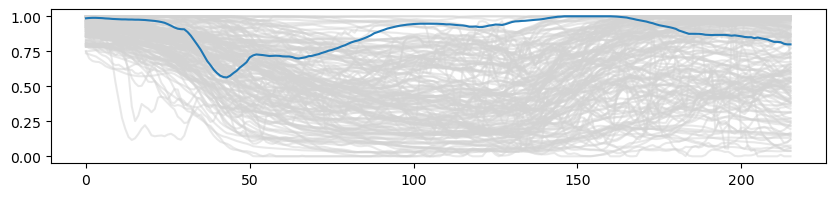

In [7]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}/{resource}-{method}-hyper-sa.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

asset = 0
time = 72
day = 30

# Get data for this region
F_tr_, F_ts_ = _DATA_asset['ac']
E_tr_bias_, E_ts_bias_ = _DATA_asset['day-ahead_bias_fc']
E_tr_lin_, E_ts_lin_ = _DATA_asset['day-ahead_linear_fc']
E_tr_, E_ts_ = _DATA_asset['day-ahead_fc']
t_tr_, t_ts_ = _DATA_asset['dates']
X_tr_, X_ts_ = _DATA_asset['locations'] 
dt_, dx_ = _DATA_asset['grid']

# Get functional predictors for a given test
f_ = F_ts_[day, :time, asset]
e_lin_ = E_ts_lin_[day, :, asset]
e_ = E_ts_[day, :, asset]
x_ts = X_ts_[asset, :]
t_ts = t_ts_[day]
f_hat_ = F_ts_[day, time:, asset]

# Filter solar hours with loading solar set
idx_days_  = np.absolute(t_tr_ - day) < 7
idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

_distances = {'temporal': 'seasonal', 'spatial': 'haversine'}

_fdu = functional_dynamic_update(_distances, assets_ts_[asset], T_ts_[day, time])
print(_fdu.name, _fdu.date)

_fdu.fit(F_tr_, E_tr_lin_, dt_, 
        X_ = X_tr_, 
        t_ = t_tr_, 
        interval_mask = idx_hours_)

M_ = _fdu.predict(f_, e_lin_, x_ts, t_ts,
                  forget_rate_f = hyper_.loc['forget_rate_f'][time],
                  forget_rate_e = hyper_.loc['forget_rate_e'][time],
                  length_scale_f = hyper_.loc['length_scale_f'][time],
                  length_scale_e = hyper_.loc['length_scale_e'][time],
                  lookup_rate = hyper_.loc['lookup_rate'][time],
                  trust_rate = hyper_.loc['trust_rate'][time],
                  nu = hyper_.loc['nu'][time],
                  gamma = hyper_.loc['gamma'][time],
                  xi = hyper_.loc['xi'][time],
                  kappa = hyper_.loc['kappa'][time],
                  p_fusion = hyper_.loc['p_fusion'][time])

plt.figure(figsize=(10, 2))
plt.plot(M_.T, color = 'lightgray', alpha = 0.5)
plt.plot(f_hat_)
plt.show()

                      6         12        18
parameter                                   
clique_order      2.0000    1.0000    1.0000
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     1.0000    0.0100    0.0100
lookup_rate       4.0000    2.0000    1.0000
length_scale_f    0.0050    0.0050    0.0050
length_scale_e    0.1000   10.0000   10.0000
trust_rate        0.3000    0.3000    0.1000
nu                8.0000    8.0000    8.0000
xi                0.3000    0.5000    0.6000
gamma            60.0000   50.0000   40.0000
kappa           175.0000  150.0000  125.0000
p_fusion          0.9000    0.7000    0.7500


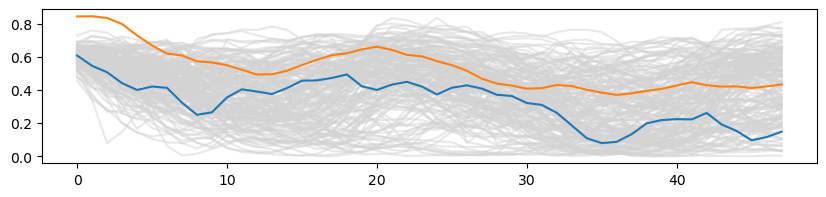

In [28]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}/{resource}-{method}-hyper-agg.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)

region = 3
time = 6
day = 120

hyper_.loc['clique_order', time] = 2
hyper_.loc['forget_rate_f', time] = 0.0625
hyper_.loc['forget_rate_e', time] = 1.
hyper_.loc['lookup_rate', time] = 4
hyper_.loc['length_scale_f', time] = 0.005
hyper_.loc['length_scale_e', time] = 0.1
hyper_.loc['nu', time] = 8
hyper_.loc['trust_rate', time] = 0.3	
hyper_.loc['xi', time] = 0.3
hyper_.loc['gamma', time] = 60
hyper_.loc['kappa', time] = 175
hyper_.loc['p_fusion', time] = 0.9

print(hyper_)

# Get data for this region
(F_tr_, F_ts_, 
E_tr_, E_ts_, 
d_tr_, d_ts_, 
t_tr_, t_ts_, 
X_tr_, X_ts_, dt_) = _load_dataset(_DATA_zone['Dataset'], regions_[region], 360)

_fdu = functional_dynamic_update({'temporal': 'seasonal', 'spatial': 'graph'}, region)

# Get functional training set
F_tr_p_ = F_tr_[:, time, :]
E_tr_p_ = np.concatenate([np.zeros((E_tr_.shape[0], 24)), E_tr_[:, time, :]], axis = 1)

_fdu.fit(F_tr_p_, E_tr_p_, dt_, 
         X_ = X_tr_, 
         t_ = d_tr_)

# Get functional predictors for a given test
f_ = F_ts_[day, time, :24]
f_hat_ = F_ts_[day, time, 24:]
e_ = E_ts_[day, time, :]
e_p_ = np.concatenate([np.zeros(24,), e_, ], axis = 0)

# Forecasting update    
M_ = _fdu.predict(f_, e_p_, X_ts_[day], d_ts_[day],
                  clique_order = hyper_.loc['clique_order'][time],
                  forget_rate_f = hyper_.loc['forget_rate_f'][time],
                  forget_rate_e = hyper_.loc['forget_rate_e'][time],
                  length_scale_f = hyper_.loc['length_scale_f'][time],
                  length_scale_e = hyper_.loc['length_scale_e'][time],
                  lookup_rate = hyper_.loc['lookup_rate'][time],
                  trust_rate = hyper_.loc['trust_rate'][time],
                  nu = hyper_.loc['nu'][time],
                  gamma = hyper_.loc['gamma'][time],
                  xi = hyper_.loc['xi'][time],
                  kappa = hyper_.loc['kappa'][time],
                  p_fusion = hyper_.loc['p_fusion'][time])

plt.figure(figsize=(10, 2))
plt.plot(M_.T, color = 'lightgray', alpha = 0.5)
plt.plot(f_hat_)
plt.plot(e_)
plt.show()

In [9]:
# # Validation set identifier
# hyper_ = pd.read_csv(path_to_param + f'/{resource}/{resource}-{method}-hyper-sa.csv')
# hyper_ = hyper_.set_index("parameter")
# hyper_.columns = hyper_.columns.astype(int)

# seed = 42

# time = 72

# lead = 2
# bins = 10
# n_intervals = 5

# # Hyperparameters for the functional forecast dynamic update:
# for i in range(12):
#     #hyper_.loc['forget_rate_f', time] = [0.0625, 0.125, 0.25, 0.5, 1., 2., 3., 4., 5., 6., 7., 8.][i]
#     hyper_.loc['length_scale_f', time] = [0.00075, 0.001, 0.0025, 0.005, 0.0075, 0.01, 0.025, 0.05, 0.075, 0.1, 0.25, 0.5][i]
#     # hyper_.loc['lookup_rate', time] = [0.5, 1., 2., 4., 8., 16., 32., 64., 128., 256., 512., 1028][i]
#     # hyper_.loc['trust_rate', time] = [0., 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.][i]
#     # hyper_.loc['nu', time] = [1., 2., 3, 4., 5, 6., 8., 10., 12., 14., 16., 18][i]
#     # hyper_.loc['gamma', time] = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120][i]
#     # hyper_.loc['xi', time] = [0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.975][i]
#     # hyper_.loc['kappa', time] = [50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325][i]
#     # hyper_.loc['p_fusion', time] = [0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.8, 0.9][i]
#     print(hyper_)

#     idx_ = np.random.default_rng(seed=seed).choice(363, size=72, replace=False)

#     M_, f_hat_, e_hat_, focal_, date_, samples_ = _run_parallel(hyper_, 
#                                                                 n_workers = 72, 
#                                                                 assets_ = range(0, 20, 1), 
#                                                                 indices_ = idx_)

#     U_ = np.array([_empirical_PIT(f_hat_[i], M_[i].T, seed = seed) for i in range(len(M_))])

#     fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  
#     ttl = 0.
#     for i in range(n_intervals):
#         _plot_PIT(ax[i], U_[:, i*12:(i + lead)*12].flatten(), 
#                     bins = bins, 
#                     title = f'Lead time {i + lead}h')
#         ax[i].set_ylim(0, 3)
#         KS = _KS(U_[:, i*12:(i + lead)*12].flatten())
#         ttl += KS
#         print(f'KS for lead time {i + lead}h: {KS}')
#     plt.show()
#     print(f'KS over lead times: {ttl}')

In [10]:
# U_ = []
# B_ = []
# S_ = []
# F_ = []
# N_ = []
# for i in range(len(M_)):
#     B_ += [f_hat_[i] - focal_[i]]
#     U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
#     S_ += [np.std(M_[i], axis = 0).mean()]
#     F_ += [focal_[i].mean()]
#     N_ += [samples_[i]]
# U_ = np.array(U_)
# B_ = np.array(B_)
# S_ = np.array(S_)
# F_ = np.array(F_)
# N_ = np.stack(N_)
# print(U_.shape, B_.shape, S_.shape, F_.shape, N_.shape)

# df_1_ = pd.DataFrame({"date": date_, "std": S_, "mean": F_, "error": E_})
# # df_1_[['asset', 'day', 'interval']] = df_1_['date'].str.split('-', expand=True)
# # df_1_['n_neighbors'] = N_[:, 0]
# # df_1_['n_temporal'] = N_[:, 1]
# # df_1_['n_spatial'] = N_[:, 2]

# # df_1_.drop(columns = ['date'], inplace = True)
# print(df_1_)

# # pd.DataFrame(U_).to_csv(path_to_validation + f'/{resource}_{method}_{time}_ts-1.csv', index = False)

In [11]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}/{resource}-{method}-hyper-sa.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)

time = 144

print(hyper_[time])

processes_test_ = [(asset, j) for asset in range(10, 12) for j in range(0, 36)]

M_, f_hat_, focal_, date_, samples_ = _run_asset_parallel(_DATA_asset, hyper_,
                                                          n_workers = 1, 
                                                          processes_ = processes_test_)

parameter
forget_rate_f       0.0625
forget_rate_e       1.0000
lookup_rate         2.0000
length_scale_f      0.0050
length_scale_e      0.0750
trust_rate          0.3000
nu                  8.0000
xi                  0.5000
gamma              50.0000
kappa             150.0000
p_fusion            0.7000
Name: 144, dtype: float64


10-0-144
10-1-144
10-2-144
10-3-144
10-4-144
10-5-144
10-6-144
10-7-144
10-8-144
10-9-144
10-10-144
10-11-144
10-12-144
10-13-144
10-14-144
10-15-144
10-16-144
10-17-144
10-18-144
10-19-144
10-20-144
10-21-144
10-22-144
10-23-144
10-24-144
10-25-144
10-26-144
10-27-144
10-28-144
10-29-144
10-30-144
10-31-144
10-32-144
10-33-144
10-34-144
10-35-144
11-0-144
11-1-144
11-2-144
11-3-144
11-4-144
11-5-144
11-6-144
11-7-144
11-8-144
11-9-144
11-10-144
11-11-144
11-12-144
11-13-144
11-14-144
11-15-144
11-16-144
11-17-144
11-18-144
11-19-144
11-20-144
11-21-144
11-22-144
11-23-144
11-24-144
11-25-144
11-26-144
11-27-144
11-28-144
11-29-144
11-30-144
11-31-144
11-32-144
11-33-144
11-34-144
11-35-144


In [12]:
B_ = []
E_ = []
U_ = []
S_ = []
F_ = []
N_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    E_ += [np.sqrt(np.mean((f_hat_[i] - focal_[i])**2))]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
    F_ += [focal_[i].mean()]
    N_ += [samples_[i]]
B_ = np.array(B_)
E_ = np.array(E_)
U_ = np.array(U_)
S_ = np.array(S_)
F_ = np.array(F_)
N_ = np.stack(N_)
print(B_.shape, E_.shape, U_.shape, S_.shape, F_.shape, N_.shape)

df_asset_ = pd.DataFrame({"date": date_, "std": S_, "mean": F_, "rmse": E_})
# df_asset_[['asset', 'day', 'interval']] = df_2_['date'].str.split('-', expand=True)
# df_asset_['n_neighbors'] = N_[:, 0]
# df_asset_['n_temporal'] = N_[:, 1]
# df_asset_['n_spatial'] = N_[:, 2]

# df_asset_.drop(columns = ['date'], inplace = True)
print(df_asset_)

# pd.DataFrame(U_).to_csv(path_to_validation + f'/{resource}_{method}_{time}_ts-2.csv', index = False)

(72, 144) (72,) (72, 144) (72,) (72,) (72, 3)
         date       std      mean      rmse
0    10-0-144  0.197610  0.374298  0.354221
1    10-1-144  0.165869  0.200622  0.120887
2    10-2-144  0.194034  0.355692  0.378253
3    10-3-144  0.160744  0.175239  0.070183
4    10-4-144  0.159999  0.185886  0.155280
..        ...       ...       ...       ...
67  11-31-144  0.212219  0.452671  0.136866
68  11-32-144  0.183653  0.252692  0.145785
69  11-33-144  0.226626  0.479919  0.240810
70  11-34-144  0.161510  0.206989  0.448786
71  11-35-144  0.211702  0.345503  0.184560

[72 rows x 4 columns]


KS from 0h to 12h: 0.10205995918630989
KS from 12h to 24h: 0.10356481481481483
KS from 24h to 36h: 0.06723302203481049
KS from 36h to 48h: 0.08944444444444444
KS from 48h to 60h: 0.13754629629629633
KS over lead times: 0.49984853677667596


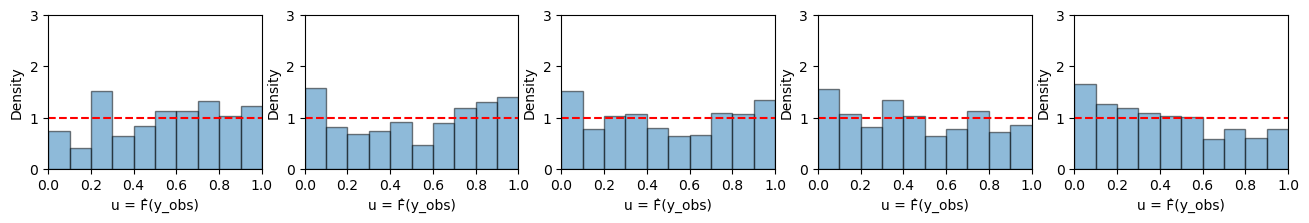

In [13]:
lead = 12

fig, ax = plt.subplots(1, 5, figsize=(16, 2))  
ttl = 0.
for i, interval in enumerate([0, 12, 24, 36, 48]):
    _plot_PIT(ax[i], U_[:, interval:(interval + lead)].flatten(), bins = 10, title = '')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, interval:(interval + lead)].flatten())
    ttl += KS

    print(f'KS from {interval }h to {interval + lead}h: {KS}')

print(f'KS over lead times: {ttl}')

plt.show()

In [42]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}/{resource}-{method}-hyper-agg.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)

time = 12

hyper_.loc['clique_order', time] = 2
hyper_.loc['forget_rate_f', time] = 1
hyper_.loc['forget_rate_e', time] = 1
hyper_.loc['lookup_rate', time] = 4
hyper_.loc['length_scale_f', time] = 0.005
hyper_.loc['length_scale_e', time] = 0.01
hyper_.loc['nu', time] = 1
hyper_.loc['trust_rate', time] = 0.3	
hyper_.loc['xi', time] = 0.8
hyper_.loc['gamma', time] = 60
hyper_.loc['kappa', time] = 260
hyper_.loc['p_fusion', time] = 0.9

print(hyper_[time])

processes_all_ = [(region, j) for region in range(5) for j in range(360)]
processes_all_shuffled_ = list(np.random.default_rng(1234).permutation(processes_all_))
processes_val_ = processes_all_shuffled_[:900]
processes_test_ = processes_all_shuffled_[900:]

M_, f_hat_, focal_, date_, samples_ = _run_zone_parallel(_DATA_zone, hyper_,
                                                         n_workers = 1, 
                                                         processes_ = processes_test_)

parameter
clique_order        2.000
forget_rate_f       1.000
forget_rate_e       1.000
lookup_rate         4.000
length_scale_f      0.005
length_scale_e      0.010
trust_rate          0.300
nu                  1.000
xi                  0.800
gamma              60.000
kappa             260.000
p_fusion            0.900
Name: 12, dtype: float64


Process ForkPoolWorker-5:
Traceback (most recent call last):
  File "/home/gterren/miniconda3/envs/fda/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/gterren/miniconda3/envs/fda/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/gterren/miniconda3/envs/fda/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/home/gterren/miniconda3/envs/fda/lib/python3.10/multiprocessing/queues.py", line 365, in get
    res = self._reader.recv_bytes()
  File "/home/gterren/miniconda3/envs/fda/lib/python3.10/multiprocessing/connection.py", line 216, in recv_bytes
    buf = self._recv_bytes(maxlength)
  File "/home/gterren/miniconda3/envs/fda/lib/python3.10/multiprocessing/connection.py", line 414, in _recv_bytes
    buf = self._recv(4)
  File "/home/gterren/miniconda3/envs/fda/lib/python3.10/multiprocessing/connection.py", line 379, in _recv
    chunk 

KeyboardInterrupt: 

In [25]:
U_ = []
E_ = []
B_ = []
S_ = []
F_ = []
N_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    E_ += [np.sqrt(np.mean((f_hat_[i] - focal_[i])**2))]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
    F_ += [focal_[i].mean()]
    N_ += [samples_[i]]
B_ = np.array(B_)
E_ = np.array(E_)
U_ = np.array(U_)
S_ = np.array(S_)
F_ = np.array(F_)
N_ = np.stack(N_)
print(B_.shape, E_.shape, U_.shape, S_.shape, F_.shape, N_.shape)

df_zone_ = pd.DataFrame({"date": date_, "std": S_, "mean": F_, "rmse": E_})
# df_zone_[['asset', 'day', 'interval']] = df_2_['date'].str.split('-', expand=True)
# df_zone_['n_neighbors'] = N_[:, 0]
# df_zone_['n_temporal'] = N_[:, 1]
# df_zone_['n_spatial'] = N_[:, 2]

# df_zone_.drop(columns = ['date'], inplace = True)
print(df_zone_)

# pd.DataFrame(U_).to_csv(path_to_validation + f'/{resource}_{method}_{time}_ts-2.csv', index = False)

(900, 48) (900,) (900, 48) (900,) (900,) (900, 3)
                 date       std      mean      rmse
0      Coastal-256-12  0.156258  0.280504  0.078504
1        South-174-12  0.172742  0.534039  0.175149
2        South-278-12  0.164400  0.361644  0.119786
3      Coastal-199-12  0.171417  0.358029  0.147375
4    Panhandle-309-12  0.198925  0.348857  0.184669
..                ...       ...       ...       ...
895      South-124-12  0.179449  0.256983  0.202187
896      North-143-12  0.177349  0.421513  0.145987
897       South-73-12  0.201547  0.364007  0.188679
898       West-339-12  0.199292  0.465396  0.244981
899  Panhandle-234-12  0.140185  0.157785  0.074587

[900 rows x 4 columns]


KS from 2h to 4h: 0.04217948717948722
KS from 4h to 6h: 0.02645299145299146
KS from 8h to 10h: 0.06572649572649569
KS from 16h to 18h: 0.04649572649572653
KS from 32h to 34h: 0.0708547008547008
KS over lead times: 0.2517094017094017


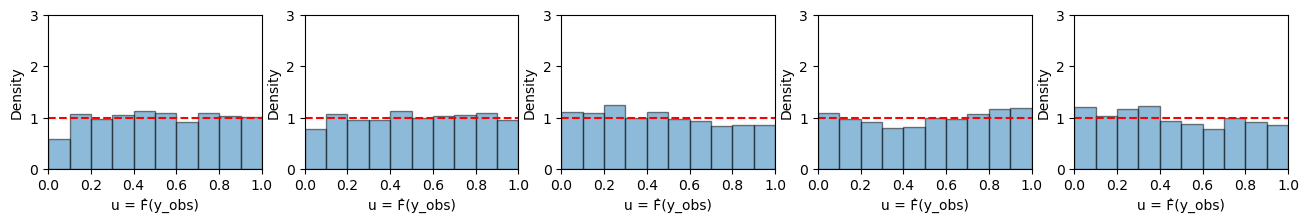

In [41]:
lead = 2

fig, ax = plt.subplots(1, 5, figsize=(16, 2))  
ttl = 0.
for i, interval in enumerate([2, 4, 8, 16, 32]):
    _plot_PIT(ax[i], U_[:, interval:(interval + lead)].flatten(), bins = 10, title = '')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, interval:(interval + lead)].flatten())
    ttl += KS

    print(f'KS from {interval }h to {interval + lead}h: {KS}')

print(f'KS over lead times: {ttl}')

plt.show()

In [ ]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)

hyper_.loc['forget_rate_e', time] = 0.5
hyper_.loc['length_scale_e', time] = 0.1
# hyper_.loc['lookup_rate', time] = 1
# hyper_.loc['gamma', time] = 40
# hyper_.loc['kappa', time] = 125
# hyper_.loc['p_fusion', time] = 0.75

print(hyper_)

time = 144

M_, f_hat_, e_hat_, focal_, date_, samples_ = _run_parallel(n_workers = 72, 
                                                            assets_ = range(20, 40, 1), 
                                                            indices_ = range(363))

                     72        144       216
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     2.0000    0.5000    0.5000
lookup_rate       2.0000    1.0000    1.0000
length_scale_f    0.0050    0.0050    0.0050
length_scale_e    0.0500    0.0750    0.1000
trust_rate        0.5000    0.3000    0.1000
nu                8.0000    8.0000    8.0000
xi                0.4000    0.5000    0.6000
gamma            60.0000   40.0000   40.0000
kappa           175.0000  125.0000  125.0000
p_fusion          0.6000    0.7500    0.7500
7260 7260 7260 7260 7260 7260


In [ ]:
U_ = []
B_ = []
E_ = []
S_ = []
F_ = []
N_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    E_ += [np.sqrt(np.mean((f_hat_[i] - e_hat_[i])**2))]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
    F_ += [focal_[i].mean()]
    N_ += [samples_[i]]
U_ = np.array(U_)
B_ = np.array(B_)
E_ = np.array(E_)
S_ = np.array(S_)
F_ = np.array(F_)
N_ = np.stack(N_)
print(U_.shape, B_.shape, E_.shape, S_.shape, F_.shape, N_.shape)

df_3_ = pd.DataFrame({"date": date_, "std": S_, "mean": F_, "error": E_})
df_3_[['asset', 'day', 'interval']] = df_3_['date'].str.split('-', expand=True)
df_3_['n_neighbors'] = N_[:, 0]
df_3_['n_temporal'] = N_[:, 1]
df_3_['n_spatial'] = N_[:, 2]
df_3_.drop(columns = ['date'], inplace = True)

pd.DataFrame(U_).to_csv(path_to_validation + f'/{resource}_{method}_{time}_ts-3.csv', index = False)

(7260, 144) (7260, 144) (7260,) (7260,) (7260,) (7260, 3)


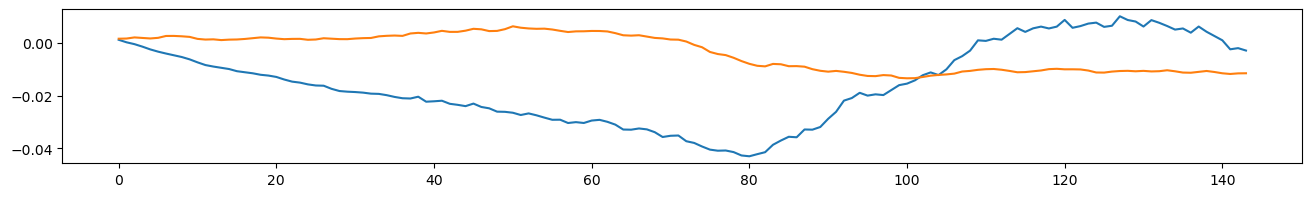

0.04301491073268392 0.013345497487032126


In [ ]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

(7260, 144) (7260, 3) 125 125
KS for lead time 1h: 0.10180716253443528
KS for lead time 2h: 0.07534259295802126
KS for lead time 3h: 0.04472522060109971
KS for lead time 4h: 0.032152382674551755


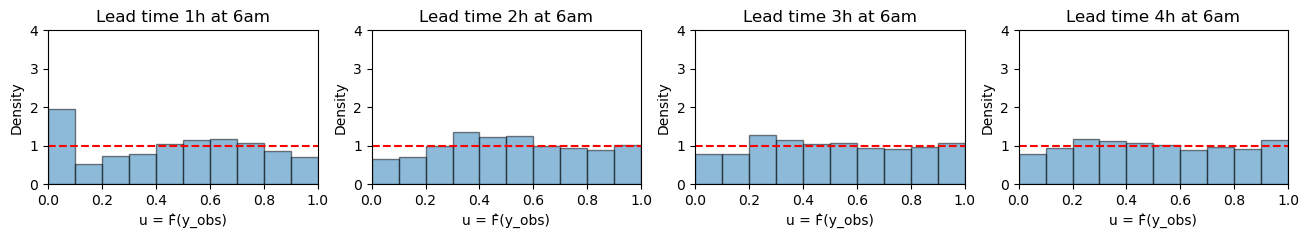

KS over lead times: 0.254027358768108


In [ ]:
print(U_.shape, N_.shape, N_[:, 2].min(), N_[:, 2].max())

lead = 1
bins = 10

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_

# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
                bins = bins, 
                title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 4)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 2h: 0.05199540863177221
KS for lead time 3h: 0.02176635666418375
KS for lead time 4h: 0.0321489898989899
KS for lead time 5h: 0.03152617079889805
KS for lead time 6h: 0.028752929365503777


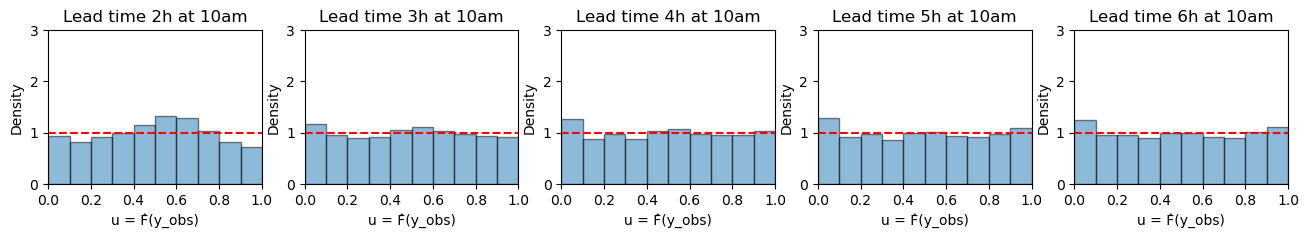

KS over lead times: 0.1661898553593477


In [ ]:
lead = 2
bins = 10
n_intervals = 5

# idx_1_ = N_[:, 2] == N_[:, 2].min()
# idx_2_ = (N_[:, 2] > N_[:, 2].min()) & (N_[:, 2] < N_[:, 2].max()) 
# idx_3_ = N_[:, 2] == N_[:, 2].max()
# idx_4_ = idx_1_ | idx_2_ | idx_3_
# idx_5_ = idx_2_ | idx_3_
# print(idx_1_.sum(), idx_2_.sum(), idx_3_.sum(), idx_4_.sum(), idx_5_.sum())

# for idx_ in [idx_1_, idx_2_, idx_3_, idx_4_, idx_5_]:

ttl = 0.

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, i*12:(i + lead)*12].flatten(), 
                bins = bins, 
                title = f'Lead time {i + lead}h at 10am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, i*12:(i + lead)*12].flatten())
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')
# KS for lead time 2h: 0.04066087962962961
# KS over lead times: 0.042971643518518454
# KS for lead time 2h: 0.03425289351851857

In [27]:
df_ = pd.concat([df_1_, df_2_, df_3_], axis = 0)    
print(df_.shape)

df_.to_csv(path_to_validation + f'/{resource}_{method}_dispersion_ts.csv', index = False)

(17400, 9)
